# Network Reach Analysis

This Section computes **network reach** — the total length of cycling network reachable from each LSOA centroid within a given distance threshold — for the West Midlands directed LTS network. Network reach captures the interplay between network density and connectivity (Peponis et al., 2008): it measures not only whether a destination *can* be reached, but the breadth of routes and locations accessible from a given origin.

The analysis focuses on an **8 km (~5 mile) distance threshold**, reflecting LTN 1/20's observation that two-thirds of all trips are within this distance and therefore represent the primary catchment for cycling as a mode substitute (DfT, 2020).

**Key methodological features:**
- **Directed graph** reach is computed on the directed network, following legal travel directions, consistent with the directed LTS classification framework.
- **Forward reachability** from each origin node, only edges traversable in the forward direction are followed — the directed analogue of the connected component approach used in undirected studies (Vierø et al., 2024).
- **Physical-road deduplication** directed edges sharing the same physical road segment (identified by `osid`) are counted only once, ensuring reach reflects accessible *physical infrastructure* rather than inflated directed-edge counts.
- **Gap closing** 30 m gaps between edges of the same LTS level are bridged before reach computation, following Vierø et al. (2024) and Schoner & Levinson (2014), to mitigate artificial fragmentation from mapping imprecision.
- **LSOA aggregation** results are aggregated to Lower Layer Super Output Areas (LSOAs) to enable comparison with Census commuting data and deprivation indices.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

import geopandas as gpd
import networkx as nx
from scipy.spatial import cKDTree
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

from shapely.geometry import Point, LineString, Polygon

import contextily as cx

# PySAL for spatial autocorrelation
from esda.moran import Moran, Moran_Local
from libpysal.weights import KNN

DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')
FIG_DIR = Path('../Figures')
FIG_DIR.mkdir(exist_ok=True)
CRS_BNG = 'EPSG:27700'


## 1. Configuration

### 1.1 Analysis Parameters and LTS Colour Scheme

In [2]:
# ----- Analysis parameters -----
REACH_THRESHOLD_M = 8000  # 8 km ≈ 5 miles (LTN 1/20 benchmark)
LTS_LEVELS = [1, 2, 3, 4]  # cumulative: LTS ≤ L
GAP_CLOSE_M = 30  # max gap to bridge between same-LTS edges

# ----- LTS colour scheme (consistent across all notebooks) -----
LTS_COLORS = {
    1: '#2ca02c',   # green  — low stress
    2: '#f0c929',   # yellow — moderate
    3: '#e8601c',   # orange — high stress
    4: '#d62728',   # red    — very high stress
}

# Sequential colormaps per LTS level (white → LTS colour)
LTS_CMAPS = {}
for lts, color in LTS_COLORS.items():
    LTS_CMAPS[lts] = LinearSegmentedColormap.from_list(
        f'lts{lts}', ['#f7f7f7', color]
    )

# Study area boroughs
STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]

print(f"Distance threshold: {REACH_THRESHOLD_M/1000:.0f} km ({REACH_THRESHOLD_M/1609:.0f} miles)")
print(f"LTS levels (cumulative): LTS ≤ {LTS_LEVELS}")
print(f"Gap closing threshold: {GAP_CLOSE_M} m")

Distance threshold: 8 km (5 miles)
LTS levels (cumulative): LTS ≤ [1, 2, 3, 4]
Gap closing threshold: 30 m


## 2. Data Loading

### 2.1 Study Area Boundary

In [3]:
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy()
study_area = study_area.to_crs(CRS_BNG)
study_area_union = study_area.unary_union

total_area_km2 = study_area.geometry.area.sum() / 1e6
print(f"Study area: {len(STUDY_AREA_BOROUGHS)} boroughs, {total_area_km2:.1f} km²")

Study area: 7 boroughs, 901.7 km²


### 2.2 Directed LTS Network

In [4]:
edges = gpd.read_file(OUTPUT_DIR / "network_lts_with_junctions.gpkg")
edges = edges.to_crs(CRS_BNG)

# Extract osid from edge_id (strip _F / _R suffix)
edges['osid'] = edges['edge_id'].str.rsplit('_', n=1).str[0]

print(f"Total directed edges: {len(edges):,}")
print(f"Unique physical segments (osid): {edges['osid'].nunique():,}")
print(f"\nLTS distribution (lts_final):")
print(edges['lts_final'].value_counts().sort_index())


Total directed edges: 480,228
Unique physical segments (osid): 257,574

LTS distribution (lts_final):
lts_final
1.0    227420
2.0    152180
3.0     46464
4.0     54164
Name: count, dtype: int64


### 2.3 LSOA Boundaries

In [5]:
lsoa_uk = gpd.read_file(
    DATA_DIR / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_-3761339731474027792.geojson"
)
lsoa_uk = lsoa_uk.to_crs(CRS_BNG)

lsoa_uk['centroid'] = lsoa_uk.geometry.centroid
lsoa_uk_centroids = lsoa_uk.set_geometry('centroid')
lsoa_wm = gpd.sjoin(lsoa_uk_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
lsoa_wm = lsoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])

print(f"LSOAs in West Midlands: {len(lsoa_wm):,}")
print(f"By borough:")
print(lsoa_wm['LAD25NM'].value_counts().sort_index())


LSOAs in West Midlands: 1,718
By borough:
LAD25NM
Birmingham       659
Coventry         203
Dudley           203
Sandwell         191
Solihull         134
Walsall          167
Wolverhampton    161
Name: count, dtype: int64


## 3. Directed Graph Construction

### 3.1 Build Base Directed Graph

Each directed edge carries its `osid` (the underlying physical road segment identifier). This is critical for the deduplication step in reach computation - when a bidirectional road produces two directed edges (`_F` and `_R`), both share the same `osid`, and the physical road length is counted only once.

In [6]:
def build_directed_graph(edges_gdf):
    """Build a NetworkX DiGraph from the directed edges GeoDataFrame."""
    G = nx.DiGraph()
    node_coords = {}
    
    for _, row in edges_gdf.iterrows():
        u = row['from_node']
        v = row['to_node']
        geom = row['geometry']
        
        G.add_edge(u, v,
                   length=row['geometry_length_m'],
                   lts=row['lts_final'],
                   facility_type=row['facility_type'],
                   edge_id=row['edge_id'],
                   osid=row['osid'])
        
        coords = list(geom.coords)
        if u not in node_coords:
            node_coords[u] = coords[0][:2]
        if v not in node_coords:
            node_coords[v] = coords[-1][:2]
    
    nx.set_node_attributes(G, {n: {'x': c[0], 'y': c[1]} for n, c in node_coords.items()})
    return G, node_coords


G_full, node_coords = build_directed_graph(edges)

print(f"Full directed graph:")
print(f"  Nodes: {G_full.number_of_nodes():,}")
print(f"  Edges: {G_full.number_of_edges():,}")


Full directed graph:
  Nodes: 253,548
  Edges: 478,430


### 3.2 Extract Cumulative LTS Subgraphs

In [7]:
def extract_lts_subgraph(G, max_lts):
    """Extract directed subgraph containing only edges with lts <= max_lts."""
    edge_list = [(u, v, d) for u, v, d in G.edges(data=True) if d['lts'] <= max_lts]
    H = nx.DiGraph()
    H.add_edges_from(edge_list)
    for n in H.nodes():
        if n in G.nodes:
            H.nodes[n].update(G.nodes[n])
    return H


lts_subgraphs = {}
for lts_level in LTS_LEVELS:
    H = extract_lts_subgraph(G_full, lts_level)
    lts_subgraphs[lts_level] = H
    
    total_length_km = sum(d['length'] for _, _, d in H.edges(data=True)) / 1000
    n_osid = len(set(d['osid'] for _, _, d in H.edges(data=True)))
    print(f"LTS ≤ {lts_level}: {H.number_of_nodes():>7,} nodes, "
          f"{H.number_of_edges():>7,} dir. edges, "
          f"{n_osid:>7,} phys. segments, "
          f"{total_length_km:>8,.1f} km dir. length")

LTS ≤ 1: 191,638 nodes, 226,475 dir. edges, 146,139 phys. segments,  9,954.5 km dir. length
LTS ≤ 2: 222,328 nodes, 378,021 dir. edges, 199,744 phys. segments, 18,021.6 km dir. length
LTS ≤ 3: 239,162 nodes, 424,402 dir. edges, 226,127 phys. segments, 20,200.2 km dir. length
LTS ≤ 4: 253,548 nodes, 478,430 dir. edges, 257,210 phys. segments, 23,151.9 km dir. length


## 4. Gap Closing

Dedicated cycling infrastructure is often mapped with geometric imprecision at intersections (Schoner & Levinson, 2014; Vierø et al., 2024). We close gaps of up to **30 m** between edges of the **same LTS level** in **different weakly connected components**, adding bidirectional bridging edges.

In [8]:
def close_gaps_directed(G, node_coords, max_gap_m, lts_level):
    """Close gaps of up to max_gap_m between disconnected components."""
    nodes_in_graph = [n for n in G.nodes() if n in node_coords]
    if len(nodes_in_graph) < 2:
        return 0
    
    node_list = list(nodes_in_graph)
    coords_array = np.array([node_coords[n] for n in node_list])
    tree = cKDTree(coords_array)
    pairs = tree.query_pairs(r=max_gap_m)
    
    comp_map = {}
    for comp_id, comp in enumerate(nx.weakly_connected_components(G)):
        for n in comp:
            comp_map[n] = comp_id
    
    gaps_closed = 0
    for i, j in pairs:
        u, v = node_list[i], node_list[j]
        if comp_map.get(u) == comp_map.get(v):
            continue
        if G.has_edge(u, v) and G.has_edge(v, u):
            continue
        
        dist = np.linalg.norm(coords_array[i] - coords_array[j])
        
        if not G.has_edge(u, v):
            G.add_edge(u, v, length=dist, lts=lts_level,
                       facility_type='gap_bridge', 
                       edge_id=f'gap_{u}_{v}', osid=f'gap_{u}_{v}')
        if not G.has_edge(v, u):
            G.add_edge(v, u, length=dist, lts=lts_level,
                       facility_type='gap_bridge',
                       edge_id=f'gap_{v}_{u}', osid=f'gap_{u}_{v}')
        
        gaps_closed += 1
        old_comp = comp_map[v]
        new_comp = comp_map[u]
        for n in list(comp_map.keys()):
            if comp_map[n] == old_comp:
                comp_map[n] = new_comp
    
    return gaps_closed


print(f"Gap closing (max {GAP_CLOSE_M} m):")
print("-" * 65)
for lts_level in LTS_LEVELS:
    H = lts_subgraphs[lts_level]
    n_comps_before = nx.number_weakly_connected_components(H)
    n_gaps = close_gaps_directed(H, node_coords, GAP_CLOSE_M, lts_level)
    n_comps_after = nx.number_weakly_connected_components(H)
    print(f"LTS ≤ {lts_level}: {n_gaps:>5,} gaps closed | "
          f"Components: {n_comps_before:>6,} → {n_comps_after:>6,} "
          f"({n_comps_before - n_comps_after:>5,} merged)")
    

Gap closing (max 30 m):
-----------------------------------------------------------------
LTS ≤ 1: 31,927 gaps closed | Components: 48,224 → 16,297 (31,927 merged)
LTS ≤ 2: 26,846 gaps closed | Components: 31,588 →  4,742 (26,846 merged)
LTS ≤ 3: 24,938 gaps closed | Components: 27,200 →  2,262 (24,938 merged)
LTS ≤ 4: 21,681 gaps closed | Components: 21,944 →    263 (21,681 merged)


## 5. Network Reach Computation

### 5.1 Nearest-Node Lookup

In [9]:
def build_node_kdtree(node_coords):
    node_list = list(node_coords.keys())
    coords_array = np.array([node_coords[n] for n in node_list])
    tree = cKDTree(coords_array)
    return tree, node_list, coords_array


node_tree, node_list_all, node_coords_array = build_node_kdtree(node_coords)

lsoa_centroids = lsoa_wm.geometry.centroid
lsoa_nearest = []

for idx, centroid in lsoa_centroids.items():
    dist, i = node_tree.query([centroid.x, centroid.y])
    lsoa_nearest.append({
        'LSOA21CD': lsoa_wm.loc[idx, 'LSOA21CD'],
        'centroid_x': centroid.x,
        'centroid_y': centroid.y,
        'nearest_node': node_list_all[i],
        'snap_dist_m': dist
    })

lsoa_nearest_df = pd.DataFrame(lsoa_nearest)
print(f"LSOA-to-node mapping: {len(lsoa_nearest_df):,} LSOAs")
print(f"Snap distance (m): mean={lsoa_nearest_df['snap_dist_m'].mean():.1f}, "
      f"max={lsoa_nearest_df['snap_dist_m'].max():.1f}")


LSOA-to-node mapping: 1,718 LSOAs
Snap distance (m): mean=41.6, max=414.1


### 5.2 Computing Directed Network Reach (with Physical-Road Deduplication)

Network reach from an origin node $o$ at distance threshold $d$ is

$$R(o, d) = \sum_{s \in S_d(o)} \ell(s)$$

where $S_d(o)$ is the set of **unique physical road segments** (`osid`) reachable from $o$ within network distance $d$, and $\ell(s)$ is the length of segment $s$.

A directed edge $(u, v)$ with `osid` $s$ contributes to reach if its start node $u$ is reachable within $d$. The contributed length is $\min(\ell_e, d - d_u)$ where $d_u$ is the shortest-path distance to $u$ (partial edge counting, following Peponis et al., 2008).

**Deduplication** when the same physical road appears as both `A→B` and `B→A` (i.e., both directed edges share the same `osid`), only the **maximum** partial contribution is retained. This ensures that a bidirectional road is counted once regardless of how many of its directed edges have reachable start nodes.

In [10]:
def compute_reach_from_node(G, source, threshold_m, weight='length'):
    """
    Compute directed network reach from a single source node,
    with deduplication by osid (physical road segment).
    
    Returns reach in metres.
    """
    if source not in G:
        return 0.0
    
    try:
        dist_to_nodes = nx.single_source_dijkstra_path_length(
            G, source, cutoff=threshold_m, weight=weight
        )
    except nx.NetworkXError:
        return 0.0
    
    # For each physical segment (osid), keep max partial contribution
    osid_reach = {}
    
    for u, v, data in G.edges(data=True):
        if u not in dist_to_nodes:
            continue
        
        d_u = dist_to_nodes[u]
        if d_u >= threshold_m:
            continue
        
        edge_len = data[weight]
        contributed = min(edge_len, threshold_m - d_u)
        osid = data.get('osid', data.get('edge_id', f'{u}_{v}'))
        
        # Keep max contribution per physical segment
        if osid not in osid_reach or contributed > osid_reach[osid]:
            osid_reach[osid] = contributed
    
    return sum(osid_reach.values())


# Test
test_node = lsoa_nearest_df.iloc[0]['nearest_node']
for lts in LTS_LEVELS:
    r = compute_reach_from_node(lts_subgraphs[lts], test_node, REACH_THRESHOLD_M)
    print(f"LTS ≤ {lts}: {r/1000:.2f} km reachable (first LSOA, 8 km threshold)")


LTS ≤ 1: 0.07 km reachable (first LSOA, 8 km threshold)
LTS ≤ 2: 0.07 km reachable (first LSOA, 8 km threshold)
LTS ≤ 3: 223.25 km reachable (first LSOA, 8 km threshold)
LTS ≤ 4: 2035.03 km reachable (first LSOA, 8 km threshold)


### 5.3 Batch Computation

In [13]:
import time

def compute_all_reach(lts_subgraphs, lsoa_nearest_df, threshold_m, lts_levels):
    """Compute network reach for all LSOA × LTS combinations."""
    results = []
    total = len(lsoa_nearest_df) * len(lts_levels)
    t0 = time.time()
    counter = 0
    
    for lts_level in lts_levels:
        G = lts_subgraphs[lts_level]
        print(f"\nProcessing LTS ≤ {lts_level} ({G.number_of_nodes():,} nodes, "
              f"{G.number_of_edges():,} edges)...")
        
        for _, row in lsoa_nearest_df.iterrows():
            reach_m = compute_reach_from_node(G, row['nearest_node'], threshold_m)
            results.append({
                'LSOA21CD': row['LSOA21CD'],
                'lts_level': lts_level,
                'reach_m': reach_m,
                'reach_km': reach_m / 1000
            })
            
            counter += 1
            if counter % 500 == 0:
                elapsed = time.time() - t0
                rate = counter / elapsed
                remaining = (total - counter) / rate
                print(f"  {counter:>5,}/{total:,} "
                      f"({counter/total*100:.0f}%) "
                      f"— {elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining")
    
    elapsed = time.time() - t0
    print(f"\nCompleted {total:,} computations in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    return pd.DataFrame(results)


reach_df = compute_all_reach(lts_subgraphs, lsoa_nearest_df,
                              REACH_THRESHOLD_M, LTS_LEVELS)
print(f"\nResult shape: {reach_df.shape}")



Processing LTS ≤ 1 (191,638 nodes, 290,329 edges)...
    500/6,872 (7%) — 16s elapsed, ~206s remaining
  1,000/6,872 (15%) — 31s elapsed, ~182s remaining
  1,500/6,872 (22%) — 46s elapsed, ~164s remaining

Processing LTS ≤ 2 (222,328 nodes, 431,713 edges)...
  2,000/6,872 (29%) — 70s elapsed, ~170s remaining
  2,500/6,872 (36%) — 100s elapsed, ~174s remaining
  3,000/6,872 (44%) — 129s elapsed, ~167s remaining

Processing LTS ≤ 3 (239,162 nodes, 474,278 edges)...
  3,500/6,872 (51%) — 160s elapsed, ~154s remaining
  4,000/6,872 (58%) — 195s elapsed, ~140s remaining
  4,500/6,872 (65%) — 229s elapsed, ~121s remaining
  5,000/6,872 (73%) — 264s elapsed, ~99s remaining

Processing LTS ≤ 4 (253,548 nodes, 521,792 edges)...
  5,500/6,872 (80%) — 325s elapsed, ~81s remaining
  6,000/6,872 (87%) — 395s elapsed, ~57s remaining
  6,500/6,872 (95%) — 463s elapsed, ~27s remaining

Completed 6,872 computations in 515.0s (8.6 min)

Result shape: (6872, 4)


### 5.4 Pivot and Merge

In [14]:
# Pivot to wide format
reach_wide = reach_df.pivot_table(
    index='LSOA21CD', columns='lts_level', values='reach_km'
).round(3)
reach_wide.columns = [f'reach_km_lts{int(lts)}' for lts in reach_wide.columns]
reach_wide = reach_wide.reset_index()

# Merge with LSOA geometries
lsoa_reach = lsoa_wm[['LSOA21CD', 'LSOA21NM', 'LAD25NM', 'geometry']].merge(
    reach_wide, on='LSOA21CD', how='left'
)

# Compute reach ratio
lsoa_reach['reach_ratio'] = np.where(
    lsoa_reach['reach_km_lts4'] > 0,
    lsoa_reach['reach_km_lts2'] / lsoa_reach['reach_km_lts4'],
    0
)

# Save
reach_df.to_csv(OUTPUT_DIR / 'lsoa_network_reach.csv', index=False)

print(f"LSOAs with reach data: {len(lsoa_reach):,}")
print(f"\nColumns: {[c for c in lsoa_reach.columns if 'reach' in c]}")

LSOAs with reach data: 1,718

Columns: ['reach_km_lts1', 'reach_km_lts2', 'reach_km_lts3', 'reach_km_lts4', 'reach_ratio']


## 6. Results

### 6.1 Summary Statistics

In [15]:
print("=" * 75)
print(f"Network Reach Summary — 8 km Threshold (physical road km reachable)")
print("=" * 75)
print(f"{'LTS':>8}  {'Mean':>8}  {'Median':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}  {'Zero%':>7}")
print("-" * 75)

for lts in LTS_LEVELS:
    col = f'reach_km_lts{lts}'
    s = lsoa_reach[col]
    pz = (s == 0).mean() * 100
    print(f"{'≤ ' + str(lts):>8}  {s.mean():>8.1f}  {s.median():>8.1f}  "
          f"{s.std():>8.1f}  {s.min():>8.1f}  {s.max():>8.1f}  {pz:>6.1f}%")

print(f"\nReach ratio (LTS ≤ 2 / LTS ≤ 4):")
rr = lsoa_reach['reach_ratio']
print(f"  Mean: {rr.mean():.3f}  |  Median: {rr.median():.3f}  |  Std: {rr.std():.3f}")

Network Reach Summary — 8 km Threshold (physical road km reachable)
     LTS      Mean    Median       Std       Min       Max    Zero%
---------------------------------------------------------------------------
     ≤ 1       0.7       0.1       3.0       0.0      39.9    37.0%
     ≤ 2      37.5      10.6      61.4       0.0     329.2     9.5%
     ≤ 3     112.4      61.3     119.1       0.0     536.8     4.2%
     ≤ 4    1580.9    1593.0     505.8       0.0    2479.8     0.1%

Reach ratio (LTS ≤ 2 / LTS ≤ 4):
  Mean: 0.028  |  Median: 0.007  |  Std: 0.072


### 6.2 Choropleth Maps: Network Reach at 8 km by LTS Level

Each panel uses a **per-LTS colour scale** (white → LTS colour) to reveal internal spatial variation. The colour ramp runs from white (zero reach) to the LTS-specific colour (high reach), with `vmax` set at the 98th percentile to prevent outlier compression.

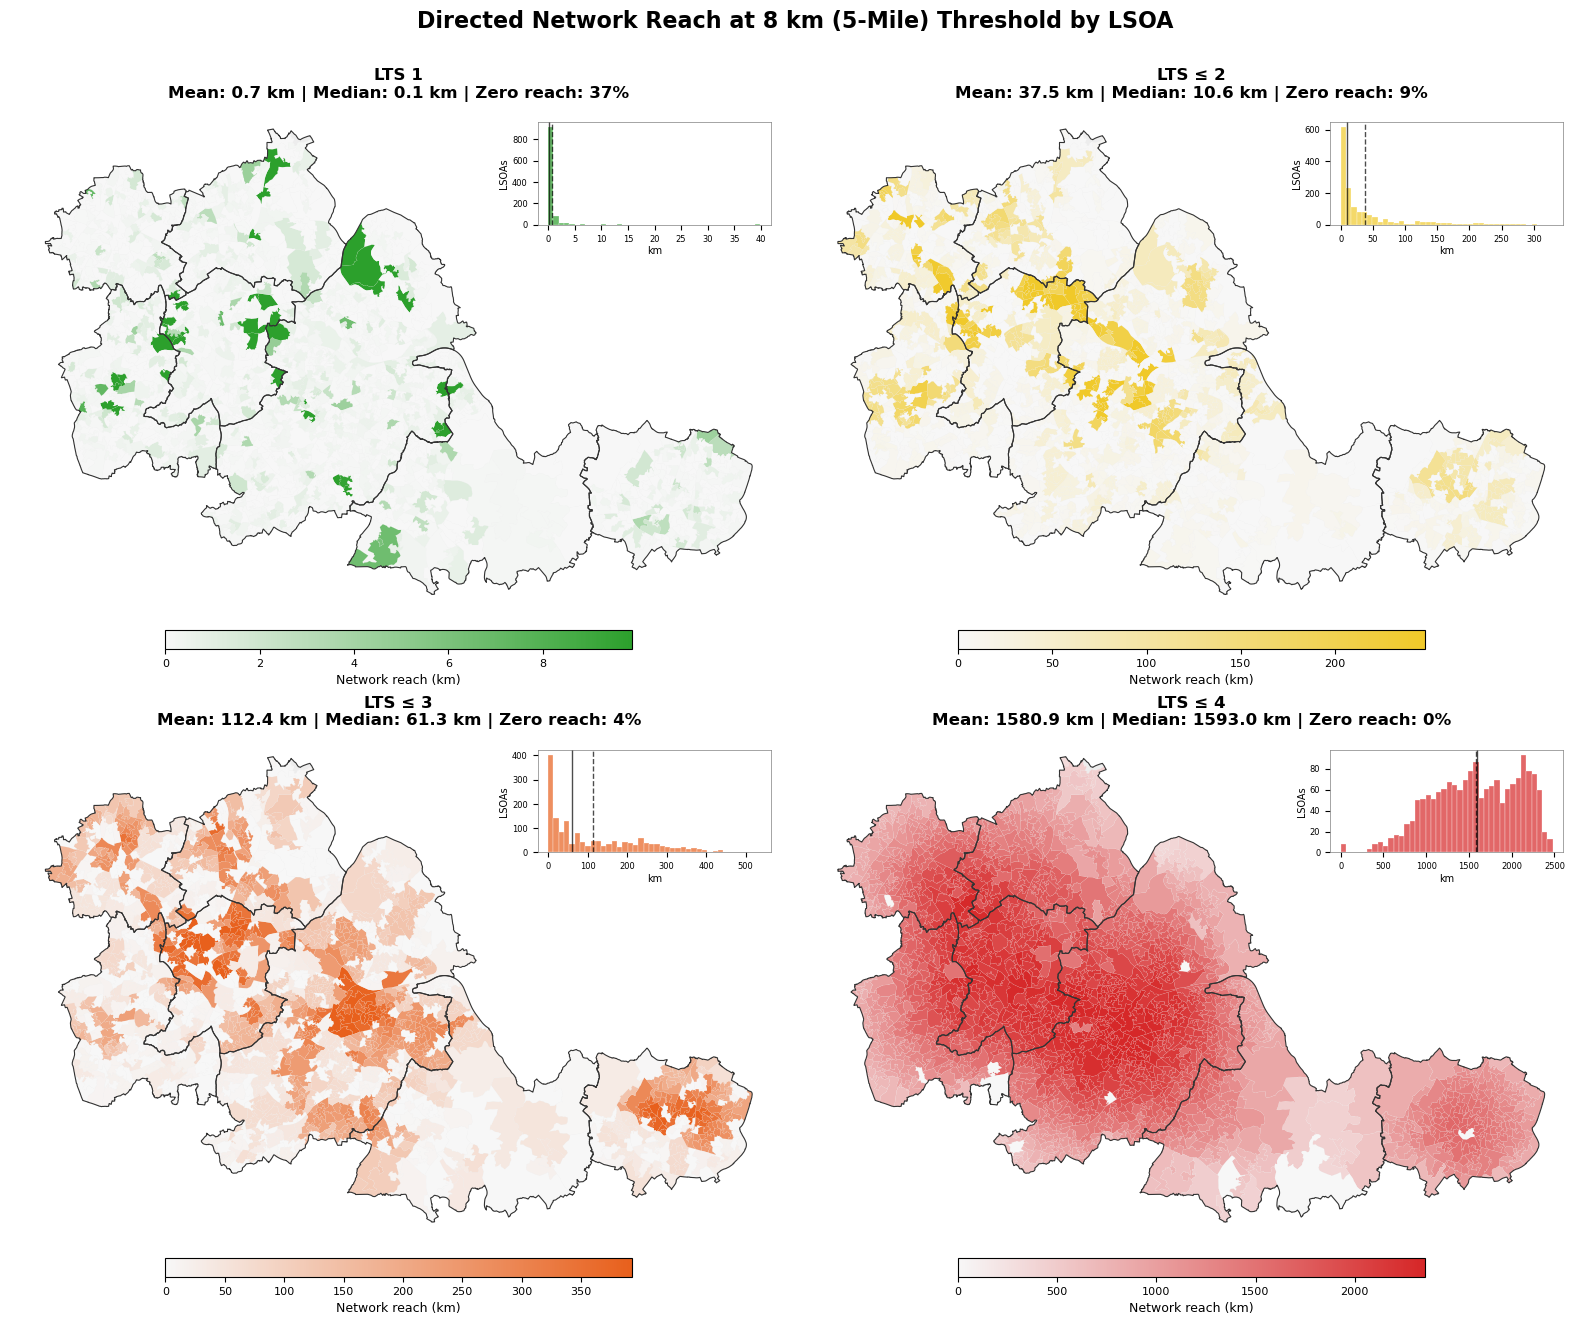

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

LTS_LABELS = {1: 'LTS 1', 2: 'LTS ≤ 2', 3: 'LTS ≤ 3', 4: 'LTS ≤ 4'}

for i, lts in enumerate(LTS_LEVELS):
    ax = axes[i]
    col = f'reach_km_lts{lts}'
    data = lsoa_reach[col]
    vmax = max(data.quantile(0.98), 0.01)
    
    mean_val = data.mean()
    median_val = data.median()
    pct_zero = (data == 0).mean() * 100
    
    # Background fill
    study_area.plot(ax=ax, color='#ededed', edgecolor='none')
    
    # Choropleth
    lsoa_reach.plot(
        column=col, ax=ax,
        cmap=LTS_CMAPS[lts],
        vmin=0, vmax=vmax,
        edgecolor='white', linewidth=0.05,
        missing_kwds={'color': '#ededed'}
    )
    study_area.boundary.plot(ax=ax, color='#333333', linewidth=0.8)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=LTS_CMAPS[lts],
                                norm=plt.Normalize(vmin=0, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                        shrink=0.6, pad=0.02, aspect=25)
    cbar.set_label('Network reach (km)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    
    # Title with stats
    ax.set_title(f'{LTS_LABELS[lts]}\n'
                 f'Mean: {mean_val:.1f} km | Median: {median_val:.1f} km | '
                 f'Zero reach: {pct_zero:.0f}%',
                 fontsize=12, fontweight='bold')
    ax.set_axis_off()
    
    # Inset distribution (top-right)
    ax_inset = inset_axes(ax, width='30%', height='20%', loc='upper right',
                          borderpad=1.2)
    
    nonzero = data[data > 0]
    if len(nonzero) > 10:
        ax_inset.hist(nonzero, bins=40, color=LTS_COLORS[lts],
                      alpha=0.7, edgecolor='white', linewidth=0.3)
        ax_inset.axvline(mean_val, color='black', linestyle='--',
                         linewidth=1, alpha=0.7)
        ax_inset.axvline(median_val, color='black', linestyle='-',
                         linewidth=1, alpha=0.7)
    
    ax_inset.set_xlabel('km', fontsize=7, labelpad=2)
    ax_inset.set_ylabel('LSOAs', fontsize=7, labelpad=2)
    ax_inset.tick_params(labelsize=6)
    ax_inset.set_facecolor('white')
    ax_inset.patch.set_alpha(0.85)
    for spine in ax_inset.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)

fig.suptitle('Directed Network Reach at 8 km (5-Mile) Threshold by LSOA',
             fontsize=16, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 6.3 Reach Ratio Map

The reach ratio $R_{\text{ratio}} = R_{\text{LTS} \leq 2} / R_{\text{LTS} \leq 4}$ measures what proportion of the full reachable network is accessible at low stress. This metric is directly policy-relevant - it shows where cyclists are forced onto high-stress roads to access destinations within cycling distance.

### 6.4 Borough-Level Comparison

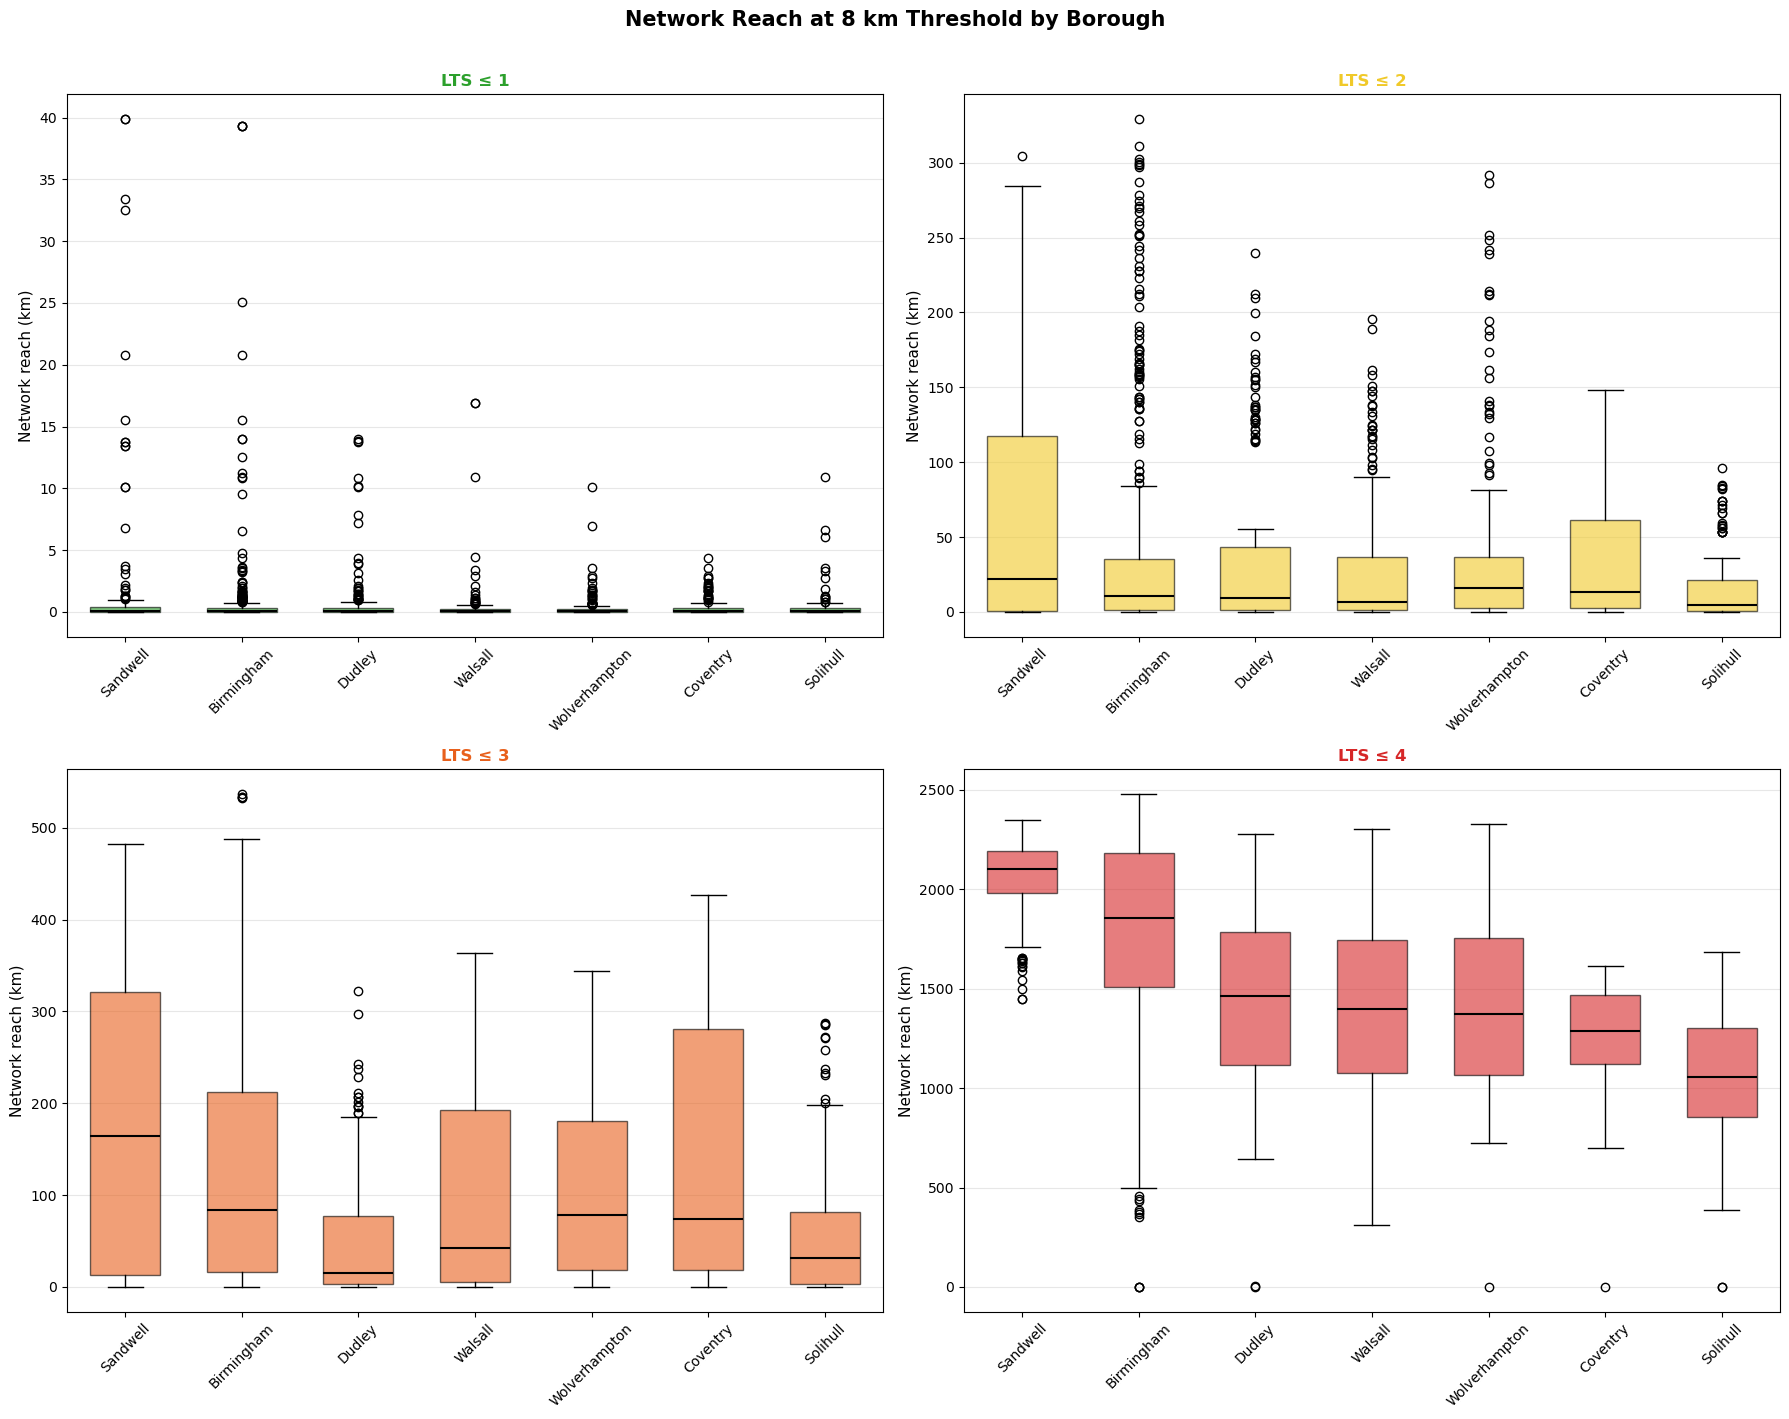

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

borough_order = (lsoa_reach.groupby('LAD25NM')['reach_km_lts4']
                 .median().sort_values(ascending=False).index)

for i, lts in enumerate(LTS_LEVELS):
    ax = axes[i]
    col = f'reach_km_lts{lts}'
    
    data_by_borough = [lsoa_reach.loc[lsoa_reach['LAD25NM'] == b, col].values
                       for b in borough_order]
    
    bp = ax.boxplot(data_by_borough, labels=borough_order,
                    patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.5))
    
    for patch in bp['boxes']:
        patch.set_facecolor(LTS_COLORS[lts])
        patch.set_alpha(0.6)
    
    ax.set_ylabel('Network reach (km)', fontsize=11)
    ax.set_title(f'LTS ≤ {lts}', fontsize=12, fontweight='bold',
                 color=LTS_COLORS[lts])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Network Reach at 8 km Threshold by Borough',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'reach_borough_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Decomposition by Facility Type

In [18]:
def compute_reach_by_facility(G, source, threshold_m, weight='length'):
    """Compute reach decomposed by facility type, with osid deduplication."""
    if source not in G:
        return {}
    
    try:
        dist_to_nodes = nx.single_source_dijkstra_path_length(
            G, source, cutoff=threshold_m, weight=weight
        )
    except nx.NetworkXError:
        return {}
    
    # {osid: (facility_type, max_contributed_length)}
    osid_info = {}
    
    for u, v, data in G.edges(data=True):
        if u not in dist_to_nodes:
            continue
        d_u = dist_to_nodes[u]
        if d_u >= threshold_m:
            continue
        
        contributed = min(data[weight], threshold_m - d_u)
        osid = data.get('osid', data.get('edge_id', f'{u}_{v}'))
        fac = data.get('facility_type', 'Unknown')
        
        if osid not in osid_info or contributed > osid_info[osid][1]:
            osid_info[osid] = (fac, contributed)
    
    reach_by_fac = defaultdict(float)
    for fac, length in osid_info.values():
        reach_by_fac[fac] += length
    
    return dict(reach_by_fac)


# Sample 200 LSOAs
np.random.seed(42)
sample_idx = np.random.choice(len(lsoa_nearest_df),
                               size=min(200, len(lsoa_nearest_df)), replace=False)
sample_lsoas = lsoa_nearest_df.iloc[sample_idx]

print(f"Facility-type decomposition: {len(sample_lsoas)} sampled LSOAs, 8 km threshold")

fac_results = []
for lts in LTS_LEVELS:
    G = lts_subgraphs[lts]
    for _, row in sample_lsoas.iterrows():
        reach_fac = compute_reach_by_facility(G, row['nearest_node'], REACH_THRESHOLD_M)
        for fac, length in reach_fac.items():
            fac_results.append({
                'lts_level': lts, 'facility_type': fac, 'reach_km': length / 1000
            })

fac_df = pd.DataFrame(fac_results)
fac_summary = fac_df.groupby(['lts_level', 'facility_type'])['reach_km'].mean().reset_index()

print("\nMean reach (km) by facility type:")
for lts in LTS_LEVELS:
    print(f"\nLTS ≤ {lts}:")
    sub = fac_summary[fac_summary['lts_level'] == lts].sort_values('reach_km', ascending=False)
    for _, row in sub.iterrows():
        print(f"  {row['facility_type']:>25}: {row['reach_km']:>8.2f} km")

Facility-type decomposition: 200 sampled LSOAs, 8 km threshold

Mean reach (km) by facility type:

LTS ≤ 1:
                   Off-Road:     1.00 km
                 Shared Use:     0.28 km
              Mixed Traffic:     0.26 km
        Advisory Cycle Lane:     0.16 km
   Fully Kerbed Cycle Track:     0.16 km
                 gap_bridge:     0.09 km

LTS ≤ 2:
              Mixed Traffic:    24.50 km
                   Off-Road:     9.81 km
                 gap_bridge:     1.46 km
                 Shared Use:     0.69 km
   Fully Kerbed Cycle Track:     0.59 km
          Light Segregation:     0.35 km
        Stepped Cycle Track:     0.12 km
       Mandatory Cycle Lane:     0.07 km
        Advisory Cycle Lane:     0.05 km

LTS ≤ 3:
              Mixed Traffic:    82.19 km
                   Off-Road:    22.10 km
                 gap_bridge:     3.62 km
                 Shared Use:     1.27 km
          Light Segregation:     0.56 km
   Fully Kerbed Cycle Track:     0.47 km
        Adv

## 9. Export

In [20]:
output_cols = ['LSOA21CD', 'LSOA21NM', 'LAD25NM'] + \
              [f'reach_km_lts{l}' for l in LTS_LEVELS] + \
              ['reach_ratio'] + \
              ['geometry']

lsoa_reach[output_cols].to_file(OUTPUT_DIR / 'lsoa_network_reach.gpkg', driver='GPKG')
csv_cols = [c for c in output_cols if c != 'geometry']
lsoa_reach[csv_cols].to_csv(OUTPUT_DIR / 'lsoa_network_reach_summary.csv', index=False)

print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nLSOAs:     {len(lsoa_reach):,}")
print(f"Threshold: {REACH_THRESHOLD_M/1000:.0f} km ({REACH_THRESHOLD_M/1609:.0f} miles)")
print(f"Gap close: {GAP_CLOSE_M} m")
print(f"\nOutputs:")
print(f"  lsoa_network_reach.gpkg")
print(f"  lsoa_network_reach.csv")
print(f"  lsoa_network_reach_summary.csv")
print(f"  Figures → {FIG_DIR}/")

ANALYSIS COMPLETE

LSOAs:     1,718
Threshold: 8 km (5 miles)
Gap close: 30 m

Outputs:
  lsoa_network_reach.gpkg
  lsoa_network_reach.csv
  lsoa_network_reach_summary.csv
  Figures → ../Figures/
